In [34]:
import geopandas as gpd

# gdf = gpd.read_file("/mnt/data2/le000415/Prof_Ding_Lab/OU_Datasets_0302/tornados_shp/tor7/nws_dat_damage_pnts.shp")

gdf = gpd.read_file("/mnt/data2/le000415/Prof_Ding_Lab/OU_Datasets_0302/tornados_shp/tor10/nws_dat_damage_pnts.shp")
print(gdf.head())

   Id  stormdate stormtime surveydate surveytime event_id  damage  \
0   0 2011-04-27  2140 UTC 2011-04-28   1600 UTC      PDR     2.0   
1   0 2011-04-27  2140 UTC 2011-04-28   1600 UTC      PDR     2.0   
2   0 2011-04-27  2140 UTC 2011-04-28   1600 UTC      PDR     2.0   
3   0 2011-04-27  2140 UTC 2011-04-28   1600 UTC      PDR     2.0   
4   0 2011-04-27  2140 UTC 2011-04-28   1600 UTC      PDR     2.0   

                             damage_txt  \
0  One- or Two-Family Residences (FR12)   
1  One- or Two-Family Residences (FR12)   
2  One- or Two-Family Residences (FR12)   
3  One- or Two-Family Residences (FR12)   
4  One- or Two-Family Residences (FR12)   

                                             dod_txt efscale  ...      lat  \
0  Most walls collapsed, except small interior rooms     EF3  ...  34.8437   
1  Most walls collapsed, except small interior rooms     EF3  ...  34.8550   
2  Large sections of roof structure removed; most...     EF3  ...  34.8546   
3             

<Axes: >

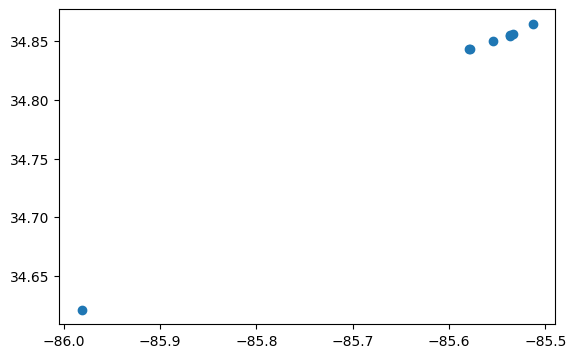

In [35]:
gdf.plot()

In [36]:
# print("CRS:", gdf.crs)
# print("Any empty geometries:", gdf.geometry.is_empty.sum())
# print("Any null geometries:", gdf.geometry.isna().sum())
# print("Total bounds:", gdf.total_bounds)   # [minx, miny, maxx, maxy]
# print(gdf.head(3))

In [37]:
import rasterio

tif_path = "/mnt/data2/le000415/Prof_Ding_Lab/OU_Datasets_0302/TOR7_BEST_AFTER_win45d.tif" 
with rasterio.open(tif_path) as src:
    print("Raster CRS:", src.crs)
    print("Raster shape:", (src.height, src.width))
    print("Raster transform:", src.transform)

Raster CRS: EPSG:4326
Raster shape: (1618, 2483)
Raster transform: | 0.00, 0.00,-87.02|
| 0.00,-0.00, 34.50|
| 0.00, 0.00, 1.00|


In [38]:
import geopandas as gpd

shp_path = "/mnt/data2/le000415/Prof_Ding_Lab/OU_Datasets_0302/tornados_shp/tor10/nws_dat_damage_pnts.shp"
gdf = gpd.read_file(shp_path)

with rasterio.open(tif_path) as src:
    raster_crs = src.crs

gdf = gdf.to_crs(raster_crs)
print("gdf CRS:", gdf.crs, "rows:", len(gdf))

gdf CRS: GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]] rows: 8


In [39]:
print(gdf.geometry.geom_type.value_counts())

Point    8
Name: count, dtype: int64


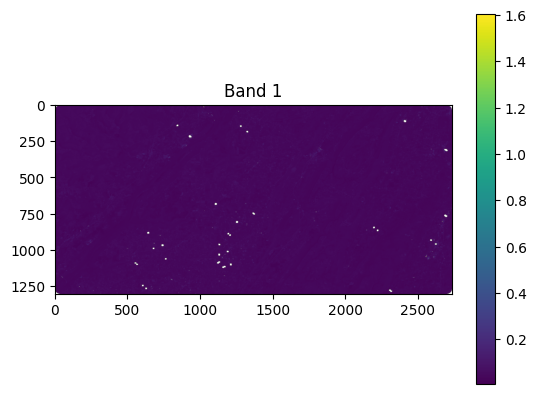

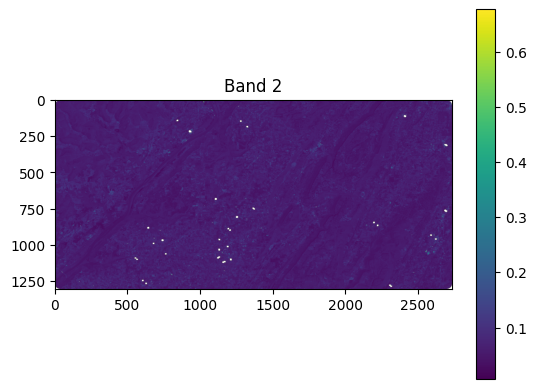

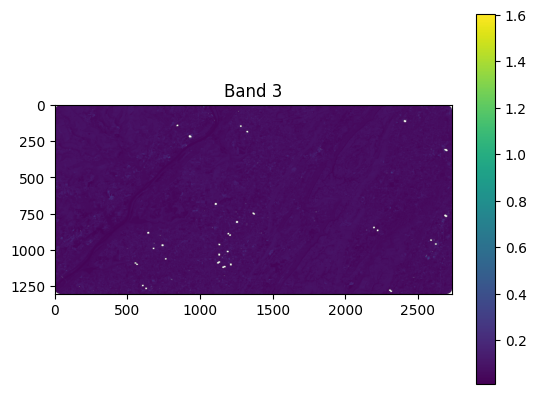

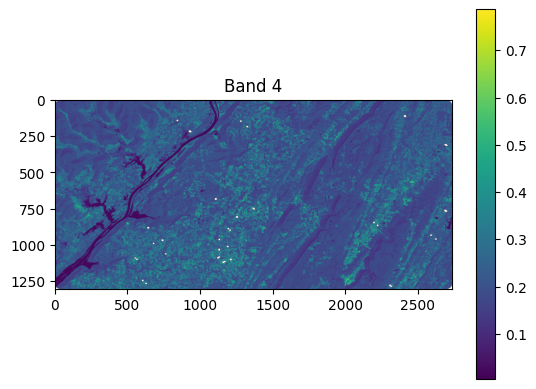

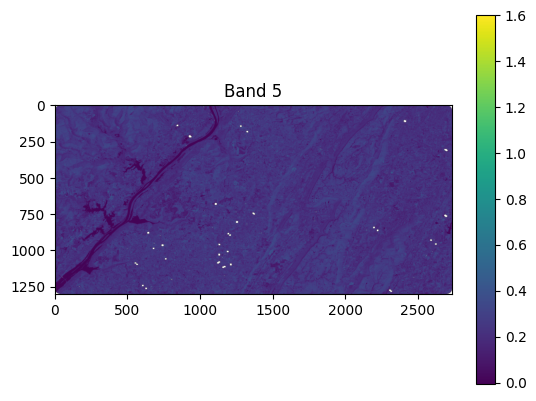

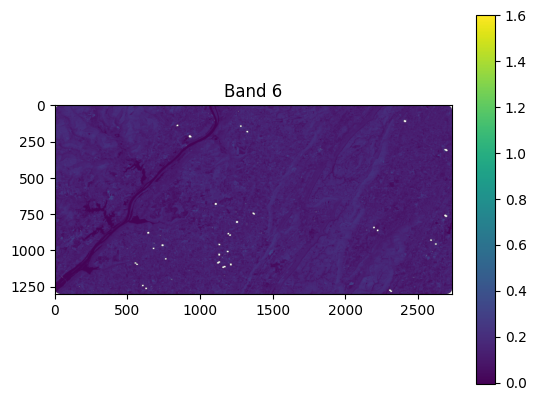

In [40]:
import tifffile as tiff
import matplotlib.pyplot as plt

tor7_after = tiff.imread("/mnt/data2/le000415/Prof_Ding_Lab/OU_Datasets_0302/TOR10_BEST_BEFORE_win25d.tif")

for i in range(6):
    plt.figure()
    plt.imshow(tor7_after[:,:,i])
    plt.title(f"Band {i+1}")
    plt.colorbar()

Text(0.5, 1.0, 'False color 4-3-2')

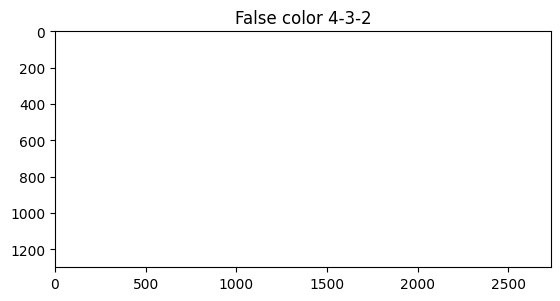

In [41]:
rgb = tor7_after[:,:,[3,2,1]]   # python index
plt.imshow(rgb / rgb.max())
plt.title("False color 4-3-2")

In [42]:
print(tor7_after.shape)
print(tor7_after.dtype)

import numpy as np
print("min:", np.nanmin(tor7_after))
print("max:", np.nanmax(tor7_after))

(1301, 2735, 6)
float32
min: -0.008655
max: 1.6022125


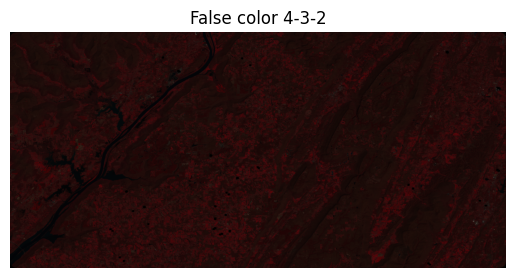

In [43]:
rgb = tor7_after[:, :, [3,2,1]]  # bands 4-3-2

rgb = np.nan_to_num(rgb)

rgb = (rgb - rgb.min()) / (rgb.max() - rgb.min())

plt.imshow(rgb)
plt.title("False color 4-3-2")
plt.axis("off")
plt.show()

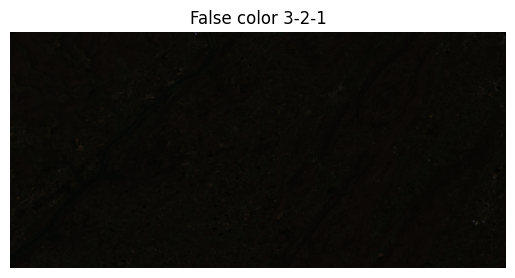

In [44]:
rgb = tor7_after[:, :, [2,1,0]]  # bands 3-2-1

rgb = np.nan_to_num(rgb)

rgb = (rgb - rgb.min()) / (rgb.max() - rgb.min())

plt.imshow(rgb)
plt.title("False color 3-2-1")
plt.axis("off")
plt.show()

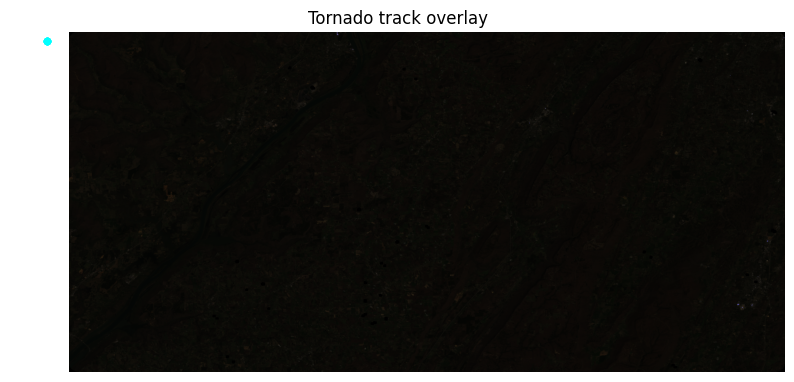

In [45]:
plt.figure(figsize=(10,8))

plt.imshow(rgb)   # your 4-3-2 image

x = gdf.geometry.x
y = gdf.geometry.y

plt.scatter(x, y, c="cyan", s=20)

plt.title("Tornado track overlay")
plt.axis("off")

plt.show()

In [46]:
for c in range(6):
    ch = tor7_after[:,:,c]
    print(
        f"Channel {c}:",
        "min =", np.nanmin(ch),
        "max =", np.nanmax(ch),
        "mean =", np.nanmean(ch),
        "std =", np.nanstd(ch)
    )

Channel 0: min = 0.0071025 max = 1.6022125 mean = 0.040165834 std = 0.012761203
Channel 1: min = 0.00658 max = 0.67714 mean = 0.05997215 std = 0.015787205
Channel 2: min = 0.0103475 max = 1.6022125 mean = 0.067608535 std = 0.020384025
Channel 3: min = 0.0045175 max = 0.7866175 mean = 0.2155332 std = 0.07198784
Channel 4: min = -0.008655 max = 1.6022125 mean = 0.22476047 std = 0.060713492
Channel 5: min = -0.0085175 max = 1.6022125 mean = 0.13133466 std = 0.0423117


Valid pixel percentage: 0.9980807900546198


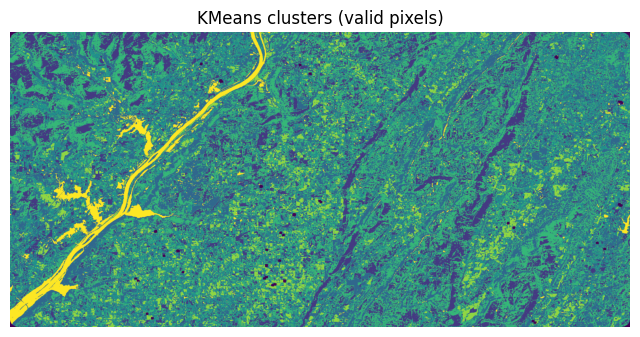

In [47]:
import numpy as np

# create valid pixel mask
valid = np.isfinite(tor7_after).all(axis=2)

print("Valid pixel percentage:", valid.mean())

from sklearn.cluster import KMeans

X = tor7_after[valid]   # shape (N_valid, 6)
kmeans = KMeans(n_clusters=6, random_state=0, n_init="auto")
labels = kmeans.fit_predict(X)

cluster_map = np.full(valid.shape, -1, dtype=int)
cluster_map[valid] = labels

plt.figure(figsize=(8,6))
plt.imshow(cluster_map)
plt.title("KMeans clusters (valid pixels)")
plt.axis("off")
plt.show()

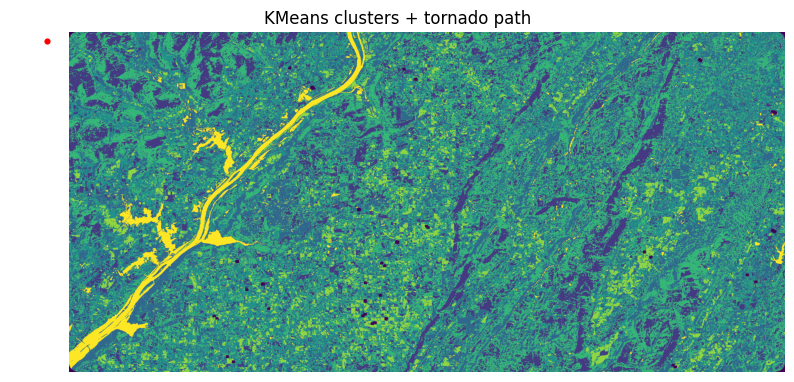

In [48]:
plt.figure(figsize=(10,7))

plt.imshow(cluster_map)

# tornado track points
plt.scatter(gdf.geometry.x, gdf.geometry.y, 
            c='red', s=30, edgecolors='white')

plt.title("KMeans clusters + tornado path")
plt.axis("off")

plt.show()

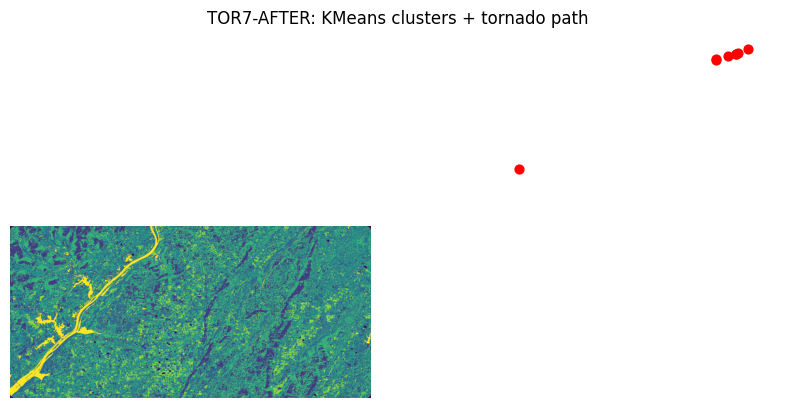

In [49]:
import rasterio

with rasterio.open(tif_path) as src:
    transform = src.transform

#######################################
from rasterio.transform import rowcol

rows = []
cols = []

for geom in gdf.geometry:
    lon = geom.x
    lat = geom.y

    r, c = rowcol(transform, lon, lat)

    rows.append(r)
    cols.append(c)

################################################
plt.figure(figsize=(10,7))

plt.imshow(cluster_map)

plt.scatter(cols, rows, c="red", s=40)

plt.title("TOR7-AFTER: KMeans clusters + tornado path")
plt.axis("off")

plt.show()